# 통계 문제

## 문제 1

빵집에서는 매일 아침에 구워지는 식빵 한 개의 평균 무게가 500g이 되도록 맞추고자 합니다. 빵집 주인은 오늘 아침에 구운 식빵 중에서 랜덤하게 25개의 식빵을 샘플링하여 무게를 측정했습니다. 그 결과, 표본 평균은 495g, 표준편차는 10g으로 나왔습니다. 빵집 주인이 목표한 500g의 무게를 충족하고 있는지(다시말해 목표 무게를 넘는지 안 넘는지)  5% 유의수준에서 검정해보세요

- 단일 표본 t-검정(one-sample t-test) 을 이용하여 빵집에서 굽는 식빵의 평균 무게가 목표값인 500g과 통계적으로 유의미한 차이가 있는지를 검정한다.

>표준오차(SE: Standard Error)
>
>표준오차는 표본 평균의 분포의 표준편차를 의미한다. 즉, 동일한 크기의 표본을 여러 번 뽑았을 때, 그 평균값들의 퍼짐 정도(변동성)를 나타낸다.
>
>$$
Standard Error = \frac{s}{\sqrt{n}}
$$
>
>- $s$: 표본 표준편차 (`sample_std`)
>- $n$: 표본 크기 (`n`)
>
> <br>
> 엄밀하게 따지면 Standard Error of the Mean(SEM)을 구하는 것이다.


In [ ]:
# [가설 설정]
#  H₀: 식빵의 평균 무게는 500g이다.
#  H₁: 식빵의 평균 무게는 500g이 아니다.
#  → 양측 검정

import numpy as np
import scipy.stats as stats

population_mean = 500    # 모집단 평균
sample_mean = 495        # 표본 평균
sample_std = 10          # 표본 표준편차
n = 25                   # 표본 크기
alpha = 0.05             # 유의수준

# 1. t-통계량 계산
#    t = (표본평균 - 모집단평균) / (표준오차)
standard_error = sample_std / np.sqrt(n)  # 표준오차
t_statistic = (sample_mean - population_mean) / standard_error

# 2. p-value 계산 (양측검정이므로 *2)
p_value = stats.t.sf(abs(t_statistic), df=n-1) * 2  # 자유도: n-1

# 3. 결과 출력
if p_value < alpha:
    print(f't-값: {t_statistic:.4f} \np-value: {p_value:.4f} \n유의수준 {alpha}에서 귀무가설을 기각합니다. 빵의 평균 무게는 목표와 다릅니다.')
else:
    print(f't-값: {t_statistic:.4f} \np-value: {p_value:.4f} \n유의수준 {alpha}에서 귀무가설을 채택합니다. 빵의 평균 무게는 목표와 통계적으로 차이가 없습니다.')

t-값: -2.5000 
p-value: 0.0197 
유의수준 0.05에서 귀무가설을 기각합니다. 빵의 평균 무게는 목표와 다릅니다.


- p-value가 0.0197로 유의수준 0.05보다 작기 때문에, 빵의 평균 무게는 목표인 500g과 다르다고 통계적으로 판단할 수 있다.

- 표본 평균은 495g으로 500g보다 작기 때문에 방향까지 고려하면 무게가 부족하여 문제가 발생할 수 있다는 것을 생각해 볼 수 있다.


<br>

## 문제 2) 분포 시각화

문제 1번을 바탕으로 분포를 그리고 t통계량을 빨간색 점선으로, 초록색 점선으로 임계값을 기각역을 초록색으로 칠해보세요.

    기각역:  통계량이 들어왔을 경우 귀무가설을 기각할 수 있는 영역을 말한다.

- `plt.axvline` : y축 평행선 그리기
- `plt.fill_between` : 그래프 면적 색칠하기

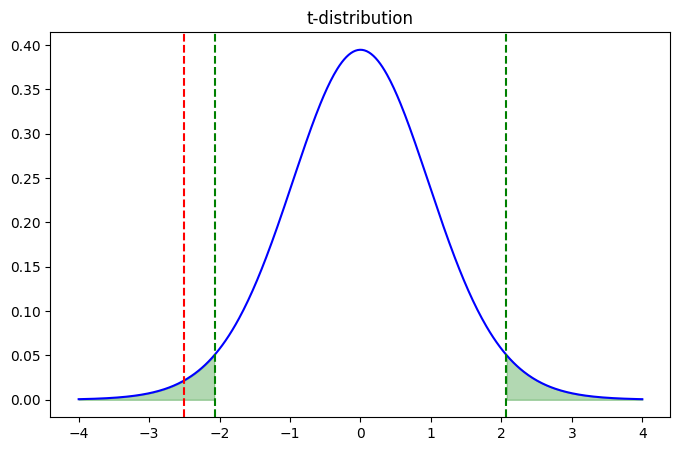

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

df = 24              # 자유도 = n - 1
alpha = 0.05         # 유의수준
t_statistic = -2.5   # 문제 1의 t-통계량

# 1. t-분포 x축 범위 설정
x = np.linspace(-4, 4, 500)
y = stats.t.pdf(x, df)  # t-분포 확률밀도함수(PDF)

# 2. 임계값 계산 (양측 검정이므로 양쪽 꼬리 각각 alpha/2)
t_critical = stats.t.ppf(1 - alpha/2, df)  # 오른쪽 임계값
# 왼쪽 임계값은 대칭이므로 -t_critical

# 3. 플롯 그리기 시작
plt.figure(figsize=(8, 5))
plt.plot(x, y, color='blue', label='t-distribution')  # t-분포 곡선

# 4. 기각역 면적 칠하기
plt.fill_between(x, y, where=(x <= -t_critical), color='green', alpha=0.3)  # 좌측 기각역
plt.fill_between(x, y, where=(x >= t_critical), color='green', alpha=0.3)   # 우측 기각역

# 5. 임계값(기각역 경계선) 표시
plt.axvline(-t_critical, color='green', linestyle='dashed', label='critical value')
plt.axvline(t_critical, color='green', linestyle='dashed')

# 6. t-통계량 표시
plt.axvline(t_statistic, color='red', linestyle='dashed', label='t-statistic')

plt.title('t-distribution')
# plt.xlabel('t-value')
# plt.ylabel('Probability Density')

plt.show()

시각화 결과, 빨간 점선(t-통계량 -2.5)은 초록색 기각역 안쪽에 위치하는 것을 확인할 수 있다.  
이는 실제 관측된 무게가 정상 범위(귀무가설 채택 구간)를 벗어났음을 보여준다.

<br>

>통계 분석 결과 식빵의 평균 무게는 495g으로 목표 무게 500g과 유의수준 5%에서 통계적으로 유의한 차이를 보였다. 시각화된 t-분포에서도 통계량이 기각역에 위치해 있어 귀무가설을 기각할 수 있음을 확인할 수 있다.  
>즉, 현재 빵집의 품질 관리 상태로는 빵의 평균 무게가 목표에 못 미치는 경향이 있으며, 이에 대한 원인 분석 및 개선이 필요하다는 생각을 해 볼 수 있다.



<br>
<br>
<br>

## 문제 3) 단일 t 표본 검정

- 어느 학교에서 새로운 교육 프로그램을 도입한 후 학생들의 수학 성적이 **향상되었는지** 확인하려고 합니다. 프로그램 도입 후 무작위로 선택한 16명의 학생들의 수학 성적 평균은 78점이고, 모집단의 평균은 75점입니다. 모집단의 표준편차는 알 수 없다고 합니다.
- 유의수준 0.05에서 이 교육 프로그램이 성적 향상에 효과가 있는지 단일 표본 t-검정을 실시하세요.


단일 표본 t-검정 (One-Sample t-test) 을 사용해 새로운 교육 프로그램의 효과가 있는지를 검정하는 문제이며, 단측검정(오른쪽 단측) 이 필요합니다. 이유는 "효과가 있다" = 성적이 증가했다 = 평균이 모집단보다 크다를 보고 싶기 때문이다.

In [ ]:
# [가설 설정]
#  H₀: 교육 프로그램은 성적 향상에 효과가 없다 (표본 평균 ≤ 모집단 평균)
#  H₁: 교육 프로그램은 성적 향상에 효과가 있다 (표본 평균 > 모집단 평균)
#  → 오른쪽 단측검정

import scipy.stats as stats

sample_scores = [79, 77, 80, 76, 78, 81, 75, 79, 77, 80, 78, 76, 82, 77, 79, 78]  # 예시 데이터
population_mean = 75  # 모집단 평균
alpha = 0.05          # 유의수준

# 1. 단일 표본 t-검정 수행
# - ttest_1samp(): 표본 평균이 주어진 모집단 평균과 통계적으로 유의미하게 다른지를 검정하는 함수
# - 이 경우에는 "새 교육 프로그램이 기존 평균(75점)보다 성적을 향상시켰는지"를 검정한다.
# - alternative='greater': 단측 검정 설정
t_stat, p_value = stats.ttest_1samp(sample_scores, popmean=population_mean, alternative='greater')

# 2. 결과 출력
if p_value < alpha:
    print(f't-값: {t_stat:.4f} \np-value: {p_value:.4f} \n유의수준 {alpha}에서 귀무가설을 기각합니다. 교육프로그램은 효과가 있습니다.')
else:
    print(f't-값: {t_stat:.4f} \np-value: {p_value:.4f} \n유의수준 {alpha}에서 귀무가설을 채택합니다. 교육프로그램은 효과가 없습니다.')

t-값: 6.7890 
p-value: 0.0000 
유의수준 0.05에서 귀무가설을 기각합니다. 교육프로그램은 효과가 있습니다.


우연이나 오차로 보기엔 p-value가 0.0000 (≈ 0) 에 가까워, 극히 유의미한 차이로 간주된다.  
기존 평균 75점이었던 수학 성적이 프로그램 후 78점으로 증가했으므로 이 차이는 실제로도 중요할 수 있다.

<br>


>통계 분석 결과, 새 교육 프로그램을 적용한 후 학생들의 수학 성적이 유의수준 5%에서 통계적으로 유의하게 향상되었음이 확인되었다. 프로그램의 효과는 우연이 아닌 실제 변화로 해석할 수 있으며, 향후 전교생 확대 도입을 위한 근거 자료로 활용 가능하다.
>
>물론, 이번 검정은 단발성 효과에 대한 분석이었기 때문에 장기적인 유지 효과나 다른 교과목에 미치는 파급 효과도 앞으로 함께 검토해야 더 설득력 있는 결론을 낼 수 있을 것이다.






<br>
<br>
<br>


## 문제 4) 독립표본 t 검정

한 연구소에서 두 가지 새로운 다이어트 프로그램의 효과를 비교하려고 합니다. 연구소는 두 그룹의 참가자들을 대상으로 12주간 다이어트 프로그램을 진행한 후 체중 감소량을 측정했습니다.  
유의수준 5% 에서 두 그룹 간 평균 체중 감소량에 유의미한 차이가 있는지 독립 표본 t-검정을 실시하세요.  
관찰연구에서는  두개의 그룹을 t검정을 할때 등분산성을 검정하게 됩니다.  scipy.stats.levene 문서를 읽고 등분산 검정 후 적절한 검정방법을 적용해보세요. 등분산 검정에도 역시 귀무가설과 대립가설이 존재합니다.  

- 두 그룹의 평균 체중 감소량에 유의미한 차이가 있는지를 독립 표본 t-검정 (independent t-test) 으로 검정하는 문제입니다. 문제 조건에 따라 등분산 검정(Levene’s test) 도 먼저 수행해야 하며, 그 결과에 따라 equal_var=True 또는 False를 설정해주어야 한다.

>**독립 표본 t-검정**
>
>"두 집단의 평균이 통계적으로 유의미하게 다른가?"
>
> 두 집단의 데이터가 서로 관련 없는(독립된) 상태에서, 평균이 단순히 우연히 다른 것인지 아니면 진짜로 의미 있는 차이가 있는 것인지를 확인하는 검정이다.
>
>해당 문제에서는 group_A와 group_B 두 그룹의 평균 체중 감소량이 통계적으로 같은 수준인가, 다른 수준인가를 검정하게 된다.






In [ ]:
# [등분산 검정의 가설]
#  H₀: 두 집단의 분산은 같다 (등분산)
#  H₁: 두 집단의 분산은 다르다 (비등분산)

# [독립 표본 t-검정의 가설]
#  H₀: 두 집단의 평균 체중 감소량은 같다
#  H₁: 두 집단의 평균 체중 감소량은 다르다
#  → 양측 검정

import scipy.stats as stats

# 그룹 A와 B의 체중 감소량 데이터
group_A = [5.1, 4.7, 6.2, 4.9, 5.3, 6.1, 5.0, 5.8, 4.8, 5.2]
group_B = [4.3, 4.1, 3.8, 4.6, 4.0, 4.5, 3.7, 4.2, 3.9, 4.4, 3.5, 4.3]

# 1. 등분산 검정 수행
levene_stat, levene_p = stats.levene(group_A, group_B)

# 2. 등분산 여부 판단: t-검정의 전제 조건 확인
equal_var = True if levene_p >= 0.05 else False

# 3. 독립 표본 t-검정 수행
# - 두 그룹 간 평균의 유의미한 차이 검정
#   cf. equal_var=True: 분산이 같다고 가정
#       equal_var=False: 분산이 다르다고 가정
t_stat, p_value = stats.ttest_ind(group_A, group_B, equal_var=equal_var)

# 4. 결과 출력
alpha = 0.05
if p_value < alpha:
    print(f't-값: {t_stat:.4f} \np-value: {p_value:.4f} \n유의수준 {alpha}에서 귀무가설을 기각합니다. 다이어트 프로그램은 효과가 있습니다.')
else:
    print(f't-값: {t_stat:.4f} \np-value: {p_value:.4f} \n유의수준 {alpha}에서 귀무가설을 채택합니다. 다이어트 프로그램은 효과가 없습니다.')

t-값: 6.3898 
p-value: 0.0000 
유의수준 0.05에서 귀무가설을 기각합니다. 다이어트 프로그램은 효과가 있습니다.


두 다이어트 프로그램의 체중 감량 효과를 비교한 결과, 프로그램 A와 B 사이에 통계적으로 유의미한 차이가 확인되었다.
- p-value = 0.0000으로, 두 다이어트 프로그램의 평균 체중 감소량 차이가 우연일 가능성은 거의 없다고 판단할 수 있다.

- 실제 t-값도 6.3898로 상당히 크기 때문에, 두 프로그램 사이 차이는 꽤 뚜렷하다고 볼 수 있다.

<br>

'어떤 프로그램이 더 나은가?'에 대한 객관적인 인사이트를 도출해 보기 위해  
두 그룹의 평균 체중 감소량을 비교해 보았다.

In [ ]:
# A와 B 그룹의 평균 체중 감소량 비교
mean_A = sum(group_A) / len(group_A)
mean_B = sum(group_B) / len(group_B)

print(f"A 그룹 평균 체중 감소량: {mean_A:.2f}kg")
print(f"B 그룹 평균 체중 감소량: {mean_B:.2f}kg")

A 그룹 평균 체중 감소량: 5.31kg
B 그룹 평균 체중 감소량: 4.11kg


두 다이어트 프로그램의 체중 감량 효과를 비교한 결과, A 프로그램 참가자의 평균 감량량은 5.31kg, B 프로그램은 4.11kg로 A가 약 1.2kg 더 높은 감량 효과를 보였다.

<br>

>t-검정 결과 이 차이는 통계적으로도 유의함이 확인되었으며, 평균 비교 결과에서 A 그룹이 더 우수한 감량 효과를 보인 것을 확인하였다. 이는 프로그램 A가 실질적이고 신뢰할 수 있는 감량 효과를 제공한다는 근거가 될 수 있다.


<br>
<br>
<br>

## 문제 5) 대응표본 t 검정

운동 프로그램 전후의 체중 변화를 분석하기 위해 10명의 참가자의 체중을 측정했습니다. 유의수준 5%에서 운동 프로그램이 체중 감소에 효과가 있는지 대응 표본 t-검정을 실시하세요.  
또한, 대응표본t검정에서 등분산 검정이 필요한지 고민해봅시다.
대응표본 t-검정은 두 집단간 평균 차이를 비교할 때 사용되는 점은 독립 t검정 동일하나, 같은 집단에서 두 번 수집할 때 사용되는 검정입니다.( ex 고혈압 투여 전후 환자 단일 그룹의 혈압의 차) scipy.stats docs에서 적절한 함수를 찾아보고 적용해보세요.  


- 대응표본 t-검정은 같은 집단에서 전후(또는 두 조건) 측정값을 비교할 때 사용하며,  
해당 문제의 요구사항인 운동 전/후 체중 비교에 적합하다.


In [ ]:
# [가설 설정]
#  H₀: 운동 프로그램은 체증 감소에 효과가 없다 (운동 전과 후의 평균 체중은 같다)
#  H₁: 운동 프로그램은 체증 감소에 효과가 있다 (운동 전과 후의 평균 체중은 다르다)
#  → 양측 검정

import numpy as np
import scipy.stats as stats

# 1. 운동 프로그램 전후의 체중 데이터
before = np.array([70, 80, 65, 90, 75, 85, 78, 82, 68, 73])
after = np.array([68, 78, 64, 88, 74, 83, 77, 80, 67, 72])
alpha = 0.05  # 유의수준

# 2. 대응표본 t-검정 수행
#    : 같은 참가자의 운동 전과 후 체중 비교
t_stat, p_value = stats.ttest_rel(before, after)

# 결과 출력
if p_value < alpha:
    print(f't-값: {t_stat:.4f} \np-value: {p_value:.4f} \n유의수준 {alpha}에서 귀무가설을 기각합니다. 운동 프로그램은 효과가 있습니다.')
else:
    print(f't-값: {t_stat:.4f} \np-value: {p_value:.4f} \n유의수준 {alpha}에서 귀무가설을 채택합니다. 운동 프로그램은 효과가 없습니다.')

t-값: 9.0000 
p-value: 0.0000 
유의수준 0.05에서 귀무가설을 기각합니다. 운동 프로그램은 효과가 있습니다.


- t-값 9.0000은 매우 큰 값으로, 그룹 간 차이가 상당히 명확하다는 것을 보여준다.
- p-value가 0.0000이라는 것은 이 결과가 우연히 발생했을 확률이 거의 0에 가깝다는 것을 보여준다.

유의수준 0.05보다 훨씬 작으므로, 귀무가설(운동 전후 평균 체중이 같다) 는 기각된다. 따라서 운동 프로그램은 체중 감량에 효과가 있다고 통계적으로 판단할 수 있다.



<br>

해석의 신뢰도를 높이기 위해 운동 프로그램 전후의 평균을 비교하여 실제로 체중이 얼마나 줄었는지 수치적으로 명확히 파악해 보았다.

In [ ]:
# 평균 값 계산
mean_before = np.mean(before)
mean_after = np.mean(after)
mean_diff = mean_before - mean_after

print(f"운동 전 평균 체중: {mean_before:.2f}kg")
print(f"운동 후 평균 체중: {mean_after:.2f}kg")
print(f"평균 체중 감소량: {mean_diff:.2f}kg")

운동 전 평균 체중: 76.60kg
운동 후 평균 체중: 75.10kg
평균 체중 감소량: 1.50kg


참가자 10명을 대상으로 한 프로그램이 평균적으로 약 1.5kg 감량되었고, 그 효과가 단순한 우연이나 오차 수준이 아니라 단기간 성과로도 충분히 의미 있는 수치라는 것을 확인하였다.

<br>

>분석 결과, 운동 프로그램은 평균적으로 약 1.5kg의 감량 효과가 있었으며, 이는 대응표본 t-검정에서도 통계적으로도 유의미한 결과임을 확인할 수 있었다. 이는 향후 더 많은 대상자에게 프로그램을 확대 적용할 근거로 활용될 수 있을 것이다.

<br>
<br>
<br>

## 문제 6) 표본 추출

Quest 05-01의  Online Retail II 데이터에서 표본을 추출하여 모집단의 평균을 추정해보세요.  
영국(United Kingdom)에서 주문된 데이터 에서 30개, 100개, 300개의 샘플을 무작위 추출하여 평균 구매 금액(Total Price)를 계산해보세요. 표본의 크기가 커질 수록 모집단의 평균과 가까워지는지 확인해보세요.  

- Online Retail II 데이터에서 영국(United Kingdom) 거래만 필터링한 후,
표본을 여러 개 추출해서 표본 평균이 모집단 평균에 얼마나 가까운지 확인한다.
- 이는 표본 크기가 커질수록 표본 평균이 모집단 평균에 가까워진다는 중심극한정리(CLT)를 이해할 수 있다.

In [ ]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")
print("Path to dataset files:", path)
retail = pd.read_csv(path + '/' + os.listdir(path)[0])
retail.head(3)

Path to dataset files: /kaggle/input/online-retail-ii-uci


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


In [ ]:
# 1. 영국(United Kingdom) 데이터 필터링
uk_data = retail[retail['Country'] == 'United Kingdom'].copy()

# 2. TotalPrice 생성
uk_data['TotalPrice'] = uk_data['Quantity'] * uk_data['Price']

# 3. 결측치 및 이상치 제거
uk_data = uk_data.dropna(subset=['TotalPrice'])
uk_data = uk_data[uk_data['TotalPrice'] > 0]

# 4. 모집단 평균 구매금액 계산
population_mean = uk_data['TotalPrice'].mean()
print(f'모집단 평균 TotalPrice: {population_mean:.2f}\n')

# 5. 표본 크기별 평균 비교
sample_sizes = [30, 100, 300]
samples = {}

for size in sample_sizes:
    sample = uk_data.sample(n=size)  # 랜덤성을 위해 시드 고정하지 않음
    samples[size] = sample           # 추후 신뢰구간 계산 등을 위해 저장
    sample_mean = sample['TotalPrice'].mean()
    print(f"Sample size: {size}, Mean TotalPrice: {sample_mean:.2f}")

모집단 평균 TotalPrice: 18.65

Sample size: 30, Mean TotalPrice: 22.66
Sample size: 100, Mean TotalPrice: 16.37
Sample size: 300, Mean TotalPrice: 18.39


- 표본 크기 30 (작은 표본)
    → 평균 22.66으로 모집단 평균보다 크게 벗어남  
    → 소수 표본에서는 표본 편차가 클 수 있다는 것을 보여줌

- 표본 크기 100
    → 평균 16.37로 오히려 낮게 추정됨   
    → 여전히 표본 수가 충분하지 않으면 우연한 왜곡 가능성 있음

- 표본 크기 300
    → 평균 18.39로 모집단 평균(18.65)에 매우 근접  
    → 표본 크기가 클수록 평균이 모집단 평균에 가까워지는 경향이 분명하게 나타남

<br>

다만 실제로 여러 번 무작위 추출을 반복해 보았을 때, 표본 크기가 30이나 100인 경우에도 우연히 모집단 평균과 매우 근접한 결과가 나오거나, 300개 표본이 오히려 더 멀어지는 경우도 확인할 수 있었다.   

표본의 크기가 커질수록 이상값이 전체 평균에 미치는 영향이 훨씬 작기 때문에 "평균적으로" 모집단 평균에 더 가깝게 수렴하는 경향이 있다. 하지만 표본 추출이 무작위(random)라는 점에서, **표본 수가 클수록 평균적으로 안정적인 추정이 가능하다**는 통계적 법칙이 반드시 매 시도마다 적용되는 건 아니라는 점을 보여준다.  

따라서 단일 표본에 의존하기보다 여러 번의 시뮬레이션 또는 부트스트래핑을 통해 평균적인 경향을 파악하는 것이 더욱 신뢰할 수 있는 접근 방식이 될 것이다.



<br>

>분석 결과, "표본이 커질수록 모집단의 특성을 더 잘 반영한다"는 사실을 직접 확인할 수 있었다. 특히 표본 크기 300에서는 모집단 평균과의 오차가 0.26으로 거의 무시할 수 있는 수준이었다. 이를 통해 표본 크기가 클수록 평균이 모집단 평균에 수렴한다는 중심극한정리의 성질을 확인할 수 있었다.
>
>데이터 수집 비용 때문에 표본 수를 최소화하려 할 때, 신뢰도 확보를 위해 어느 정도 규모가 필요한지를 정량적으로 판단하는 기준이 될 수 있을 것이다.

<br>
<br>
<br>


## 문제 7) 신뢰구간

영국 데이터에서 TotalPrice를 사용하여 95% 신뢰 구간을 계산하세요. 또한 표본의 크기가 30,100, 300으로 변하면서 신뢰구간이 변하는 형태를 확인해 보세요.  
Hint) `stats` 모듈에서 신뢰구간을 바로 구하는 함수를 확인해보세요.  

- 표본 평균의 신뢰구간(CI, Confidence Interval) 을 통해 표본 크기가 커질수록 신뢰구간이 어떻게 변하는지(좁아지는지) 확인한다.

- 표본 크기가 커질수록 신뢰구간이 더 좁아지고, 모집단 평균에 더 근접한다는 사실을 수치로 확인한다.



In [ ]:
import scipy.stats as stats

# 1. 신뢰 구간 계산 함수
def confidence_interval(data, confidence=0.95):
    """
    주어진 데이터에 대해 평균과 신뢰구간을 계산하는 함수
    - 평균: data.mean()
    - 표준 오차: stats.sem(data)
    - 신뢰구간: stats.t.interval
    """
    mean = data.mean()
    std_err = stats.sem(data)
    interval = stats.t.interval(confidence, df=len(data)-1, loc=mean, scale=std_err)
    return mean, interval

# 2. 표본 크기별 신뢰구간 비교
sample_sizes = [30, 100, 300]

for size in sample_sizes:
    sample = samples[size]  # 추출된 표본
    mean, interval = confidence_interval(sample['TotalPrice'])  # TotalPrice 컬럼만 전달

    # 신뢰구간의 너비 계산
    ci_width = interval[1] - interval[0]

    # 결과 출력
    print(f'Sample size: {size}, Mean: {mean:.2f}, 95% CI: ({interval[0]:.2f}, {interval[1]:.2f}), Width: {ci_width:.2f}')

Sample size: 30, Mean: 22.66, 95% CI: (7.19, 38.13), Width: 30.95
Sample size: 100, Mean: 16.37, 95% CI: (10.53, 22.20), Width: 11.67
Sample size: 300, Mean: 18.39, 95% CI: (13.80, 22.98), Width: 9.18


- 표본 크기가 작을수록 신뢰구간이 넓다
    → 30개 표본일 때 신뢰구간 폭이 30.95로 매우 큼

- 표본 크기가 커질수록 신뢰구간이 좁아진다
    → 300개 표본일 때 폭이 9.18로 줄어듦

이는 표본 크기가 클수록 표본 평균의 불확실성이 줄어들고, 모집단 평균에 더 근접하게 추정됨을 의미한다. 표본 수와 추정의 신뢰도 간 관계를 수치로서 확인할 수 있는 결과이다.

<br>

표를 통해 수치는 확인할 수 있었지만,  
숫자만으로는 신뢰구간의 상대적 폭 차이, 분포 모양, 평균 위치 등을 직관적으로 비교하기 어렵다.

표본 수가 크면 평균이 안정적이라는 이론을 시각적으로 확인하기 위해 CI 폭이 줄어드는 경향을 시각화해 보았다.





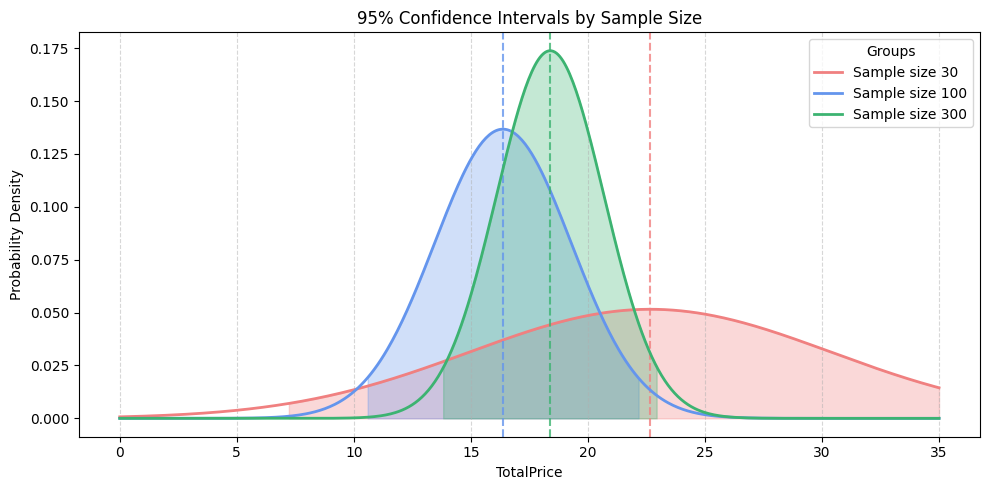

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 표본 크기별 통계값
sample_sizes = [30, 100, 300]
means = [22.66, 16.37, 18.39]
ci_lowers = [7.19, 10.53, 13.80]
ci_uppers = [38.13, 22.20, 22.98]
colors = ['lightcoral', 'cornflowerblue', 'mediumseagreen']

# X축 범위 설정
x = np.linspace(0, 35, 500)

# 그래프 생성
plt.figure(figsize=(10, 5))

for size, mean, lower, upper, color in zip(sample_sizes, means, ci_lowers, ci_uppers, colors):
    std = (upper - lower) / 4  # 95% 신뢰구간 폭 ≈ ±2σ 기준
    y = norm.pdf(x, loc=mean, scale=std)

    plt.plot(x, y, color=color, linewidth=2, label=f'Sample size {size}')
    plt.fill_between(x, 0, y, where=(x >= lower) & (x <= upper), color=color, alpha=0.3)
    plt.axvline(mean, color=color, linestyle='--', alpha=0.8)

plt.title('95% Confidence Intervals by Sample Size')
plt.xlabel('TotalPrice')
plt.ylabel('Probability Density')
plt.legend(title='Groups')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

이 그래프는 정규분포 곡선을 기반으로 각 표본의 평균과 신뢰구간을 시각적으로 보여준다.
- 표본 크기 30에서는 곡선이 완만하고 퍼져 있으며, 평균의 위치도 다른 그룹과 다르게 벗어나 있다.
- 표본 크기 300에서는 곡선이 뾰족하고 신뢰구간도 좁으며 평균이 중앙에 안정적으로 위치한다.

이로써 표본 크기가 커질수록 모집단 평균에 대한 추정 신뢰도를 높이는 것을 확인하였다.

<br>

>영국 데이터를 대상으로 총 구매 금액(TotalPrice)의 95% 신뢰구간을 표본 크기별로 비교한 결과, 표본 수가 클수록 평균 추정값의 변동성이 줄고 신뢰구간 폭도 작아지는 경향을 확인하였다. 시각화를 통해 표본 수 300에서는 신뢰구간이 가장 좁고 분포가 가장 뾰족하게 나타나며, 평균이 안정적으로 수렴하고 있음을 확인할 수 있었다.
>
>“표본 수 증가 시 평균의 정밀도 향상” 개념을 실제 데이터에 적용하여 직관적으로 이해할 수 있었다.

<br>
<br>
<br>

## 문제 8) 가설검정 t-test

영국과 독일의 고객의 평균 구매금액(Total Price)가 동일한지 검정해보세요. 귀무가설과 대립가설을 세우고 통계검정을 통해 결과를 해석하세요. (영국과 독일의 분포는 등분산성은 따른다고 가정)

In [ ]:
# [가설 설정]
#  H₀: 영국과 독일 고객의 평균 구매금액은 같다
#  H₁: 영국과 독일 고객의 평균 구매금액은 다르다
#  → 독립표본 t-검정 (양측검정, 등분산 가정)

import scipy.stats as stats

# 1. 데이터 전처리
uk_data = retail[retail['Country'] == 'United Kingdom'].copy()
germany_data = retail[retail['Country'] == 'Germany'].copy()

# 2. TotalPrice 생성
uk_data['TotalPrice'] = uk_data['Quantity'] * uk_data['Price']
germany_data['TotalPrice'] = germany_data['Quantity'] * germany_data['Price']

# 3. 결측치 및 이상치 제거
uk_data = uk_data.dropna(subset=['TotalPrice'])
uk_data = uk_data[uk_data['TotalPrice'] > 0]

germany_data = germany_data.dropna(subset=['TotalPrice'])
germany_data = germany_data[germany_data['TotalPrice'] > 0]

# 4. 독립표본 t-검정
t_stat, p_value = stats.ttest_ind(
    uk_data['TotalPrice'],
    germany_data['TotalPrice'],
    equal_var=True  # 등분산 가정
)

# 5. 결과 출력
alpha = 0.05
print(f't-통계량: {t_stat:.4f}')
print(f'p-value: {p_value:.4f}')

if p_value < alpha:
    print('유의수준 0.05에서 귀무가설을 기각합니다. 영국과 독일 고객의 평균 구매 금액에 유의한 차이가 있습니다.')
else:
    print('유의수준 0.05에서 귀무가설을 채택합니다. 영국과 독일 고객의 평균 구매 금액에 유의한 차이가 없습니다.')


t-통계량: -4.4254
p-value: 0.0000
유의수준 0.05에서 귀무가설을 기각합니다. 영국과 독일 고객의 평균 구매 금액에 유의한 차이가 있습니다.


p-value가 유의수준 0.05보다 충분히 작기 때문에, 귀무가설(평균 구매금액이 같다)을 기각할 수 있다. 즉, 영국과 독일 고객의 평균 구매금액은 통계적으로 유의한 차이가 있다고 판단된다.

통계적으로 보면 두 집단은 서로 다른 소비 패턴을 보이고 있다고 해석할 수 있을 것이다.

<br>

두 국가의 평균값이 실제로 얼마인지, 그리고 어느 쪽이 더 큰지의 검정 결과 방향을 확인하기 위해  
 두 국가의 평균값 자체를 비교해 보았다.



In [ ]:
# 영국과 독일 평균 구매금액 비교
uk_mean = uk_data['TotalPrice'].mean()
germany_mean = germany_data['TotalPrice'].mean()

print(f"영국 고객의 평균 TotalPrice: {uk_mean:.2f}")
print(f"독일 고객의 평균 TotalPrice: {germany_mean:.2f}")

영국 고객의 평균 TotalPrice: 18.65
독일 고객의 평균 TotalPrice: 25.83


두 국가의 평균 구매금액을 보면 독일 고객의 평균 구매금액이 더 높게 나타난다. 다만, 평균값 자체의 차이만으로는 통계적으로 유의한지 알 수 없고, 앞서 수행한 독립표본 t-검정의 p-value 해석을 통해 차이가 유의한지를 판단해야 한다.

결국 이 평균 비교는 해석의 참고자료로 쓰이고, 최종 판단은 t-test 결과에 기반하여야 한다.

<br>

>분석 결과, 독일 고객의 평균 구매금액이 더 높은 것으로 나타났으며 이는 독일 고객이 개별 거래당 더 많은 금액을 지출하는 경향이 있을 수 있다. 동일한 마케팅이나 가격 정책을 적용하는 것보다, 국가별로 소비 패턴의 차이를 고려한 맞춤 전략이 필요하다는 생각을 해 볼 수 있다.
>
>평균만 비교하면 단순히 수치 차이만 볼 수 있지만, 이 차이가 통계적으로 의미 있는지 여부는 반드시 검정을 통해 판단해야 힌다. 따라서 이번 분석처럼 평균 비교 + 통계 검정을 함께 수행하는 것이 중요하겠다.

<br>

---

<br>
<br>
<br>


# A/B 테스트

스타트업A에서 새로운 여행 패키지 상품 판매를 진행하고자 합니다. 패키지 판매 기획자는 새로운 패키지의 상품 판매 효율을 높이고 싶어하며, 이를 위해 기존에 상품이 판매되던 웹 페이지 (페이지 A) 가 아닌 새로운 웹 페이지 (페이지 B)를 통해 판매하고자 합니다. 패키지 판매 기획자는 신규 웹페이지 (페이지 B) 가 기존 (페이지 A) 대비 효과가 좋은 지 확인하기 위해 A/B 테스트를 진행하였습니다.

- 페이지 A: 기존에 운영하던 패키지 판매 웹 페이지
- 페이지 B: 새롭게 생성한 패키지 판매 웹 페이지

두 페이지는 스타트업A 패키지 판매 사이트에 접속하는 유저에게 랜덤으로 노출되었고, 테스트 결과는 다음과 같습니다.


|  | **노출 수** | **구매 수** |
| --- | --- | --- |
| **페이지 A** | 1000 | 80 |
| **페이지 B** | 200 | 22 |

<br>

## 문제9)

결과를 바탕으로 패키지 기획자는 페이지 B의 효과에 대해 어떤 결정을 해야 할지 서술해 주세요.  
[A/B-test calculator ](https://abtestguide.com/calc/) 를 사용하여 해석해보세요.

### 분석 결과

### 1. 테스트 목적 및 배경

패키지 기획자는 새로운 여행 패키지 상품을 웹페이지에서 판매하며, 기존 웹페이지(페이지 A) 대비 신규 웹페이지(페이지 B) 가 더 나은 판매 성과를 내는지 확인하고자 A/B 테스트를 설계하였다. 사용자는 스타트업 A의 웹사이트에 무작위로 노출되었으며, 테스트 결과는 다음과 같다. 테스트 결과 및 해석은 아래에서 자세히 설명하겠다.
<br>

| 페이지 | 노출 수 (Visitors) | 구매 수 (Conversions) | 전환율 (Conversion Rate) |
| --- | --- | --- | --- |
| A | 1000 | 80 | 8.00% |
| B | 200 | 22 | 11.00% |

<br>

### 2. 분석 방법

- 통계적 유의성 검정을 위해 단측 Z-test를 수행하였다.
- 가설 설정
    - 귀무가설(H₀): 페이지 A와 B의 전환율에 유의한 차이가 없다.
    - 대립가설(H₁): 페이지 B의 전환율이 페이지 A보다 높다.
- 신뢰수준 95% 기준, 유의수준 α = 0.05로 판단한다.

<br>


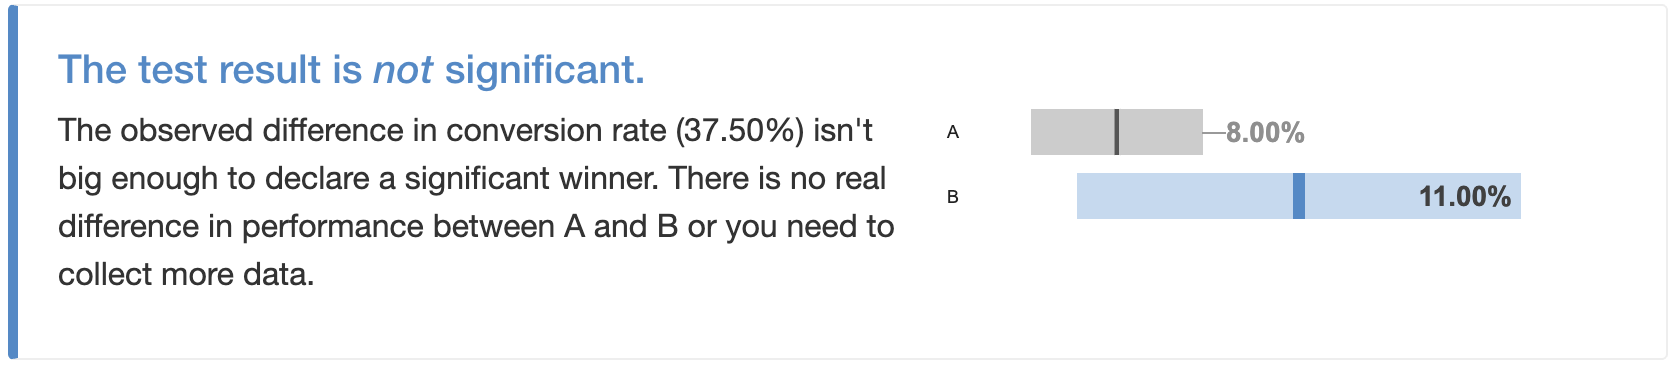

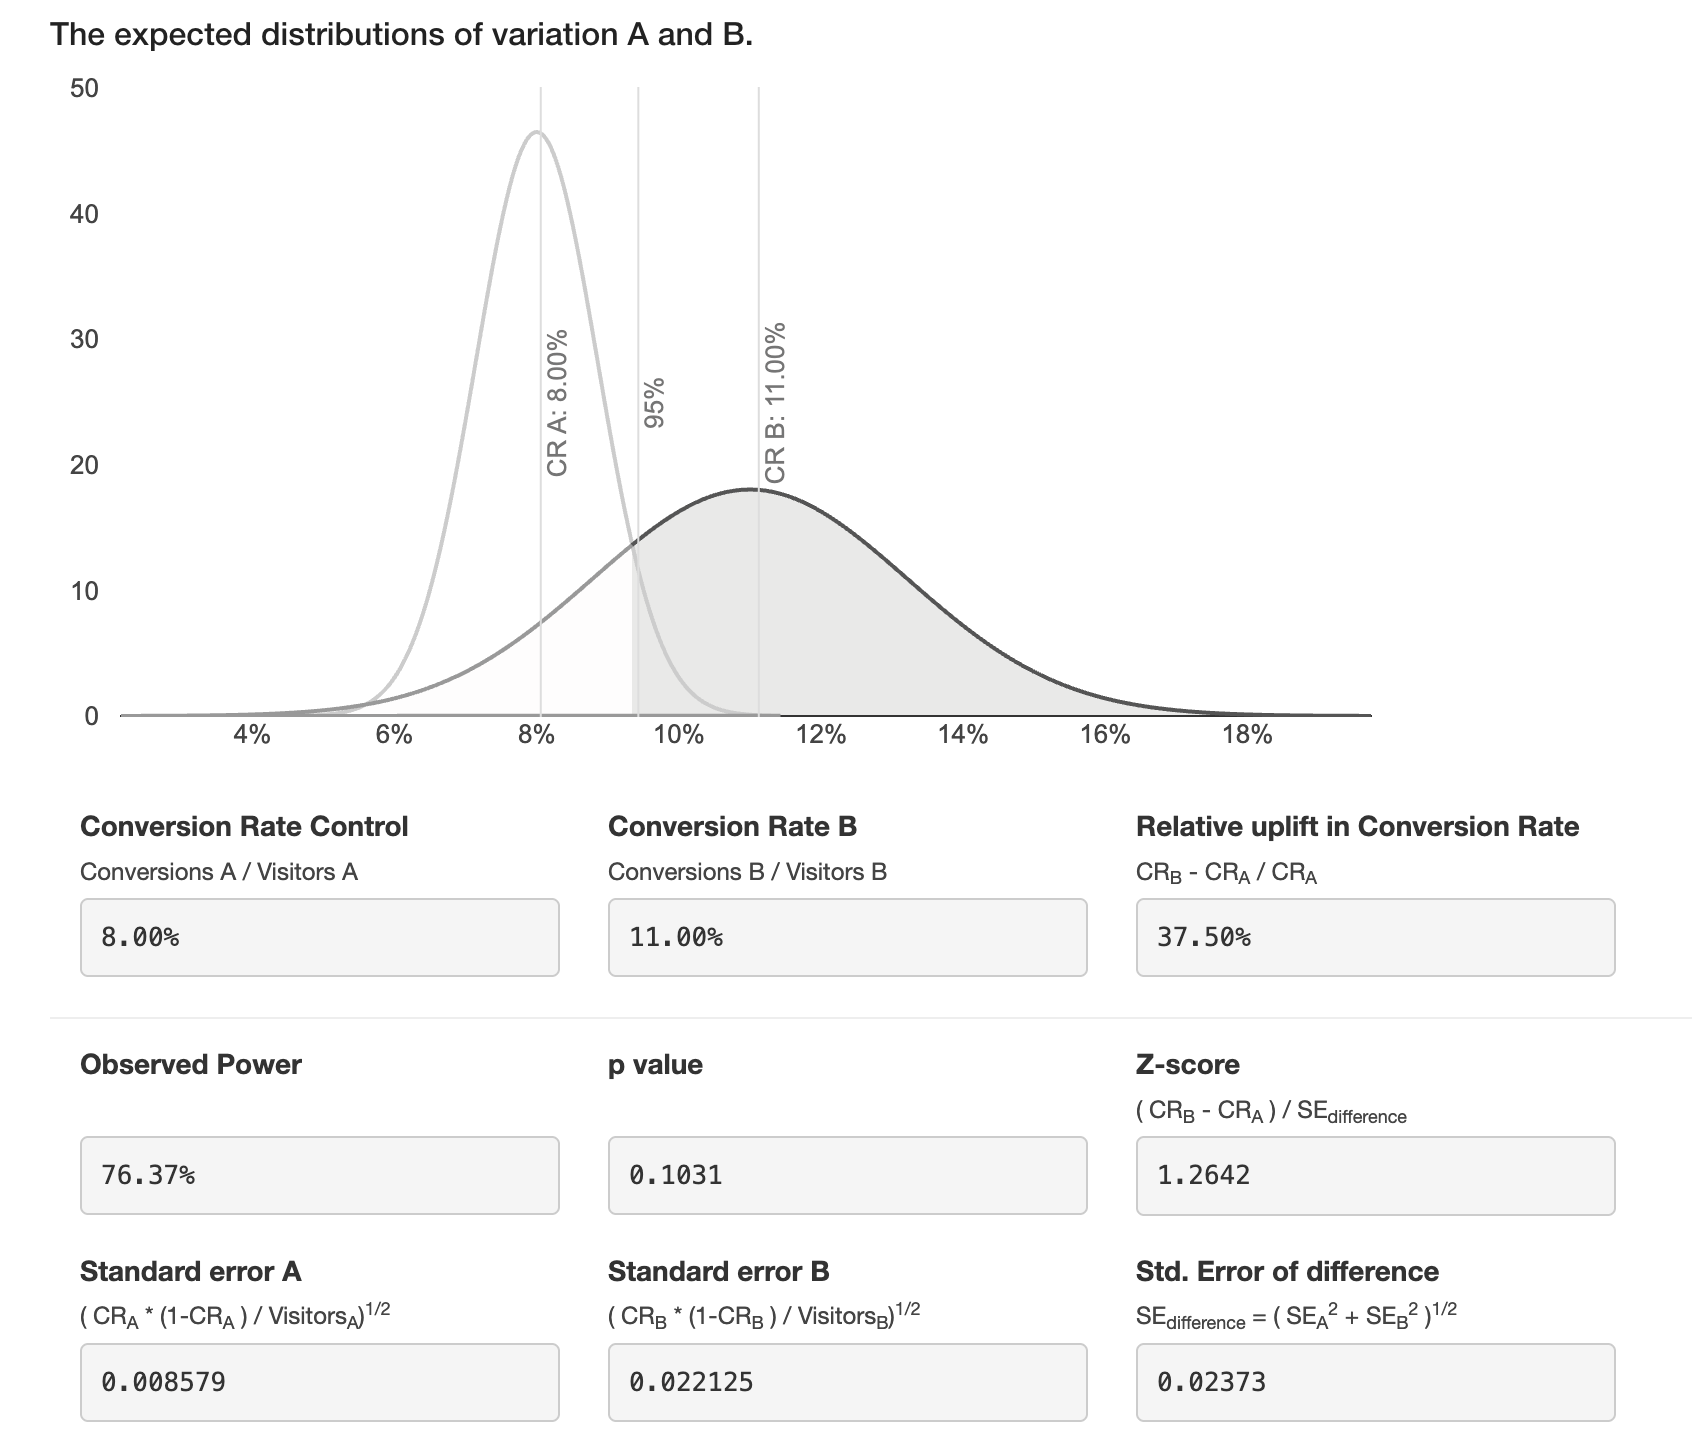



### 3. 분석 결과 요약

- Conversion Rate (CR):
    - A: 8.00%
    - B: 11.00%
    - 상대 전환율 증가율(uplift): +37.5%
- 통계 지표:
    - z-score: 1.2642
    - p-value: 0.1031
    - standard error A: 0.0086, B: 0.0221
    - 표본 간 차이의 표준 오차: 0.0237
    - power: 약 76.37%
- 검정 결과 해석:
    - p-value(0.1031) > 0.05 → 귀무가설 기각 실패
    - 통계적으로 **유의미한 차이는 없음**

<br>

### 4. 결과 해석

전환율 자체는 B가 높음에도 불구하고, 표본 수가 부족하여 이 차이가 우연에 의한 것인지 판단하기 어렵다. 실제로 Observed Power가 76.37%으로 검정의 힘도 다소 부족했다. 좀 더 많은 데이터를 수집했을 경우 유의미한 차이가 나타날 수도 있다.

전환율 차이는 존재하지만, 통계적으로 유의미한 차이는 없기 때문에 페이지 B로 더 나은 판매 성과를 낸다고 단정하여 채택하기는 이르다.
다만, 기존 대비 전환율 uplift가 37.5%인 것을 확인했으므로 잠재적인 효과는 충분히 존재한다고 볼 수 있으며, 이는 추가 실험 설계 시 고려할 만하다고 생각된다.

추가로, A/B 테스트 결과에서 분석 신뢰도에 영향을 미칠 수 있는 SRM 경고가 발생했지만 실험 설계 상 두 그룹이 반드시 50:50 비율로 나뉘었다는 명시는 없다. 문제에서 “랜덤하게 노출되었다”고만 서술되어 있는 점을 고려하면, 노출 수 차이(1000 vs. 200)는 설계 상 허용된 불균형일 가능성도 존재한다. 따라서 이번 실험에서 SRM 경고는 참고 사항으로만 받아들이고, 통계적 유의성 검정 결과를 해석하는 데 중점을 두는 것이 타당하다고 판단하였다.


<br>

>결론적으로,
>
>현재 테스트 결과만으로는 페이지 B가 A 대비 통계적으로 유의한 효과를 보인다고 판단하기는 어렵다. 하지만 전환율은 높아 보이는 만큼 패키지 기획자는 추가 데이터를 확보하거나 향후 실험 설계의 개선을 고려한 뒤, 페이지 B의 도입을 신중하게 검토하는 것이 바람직할 것이다.


<br>
<br>
<br>


## 문제 10)

A/B 테스트의 결과가 통계적으로 유의하나 효과의 차이 자체는 매우 작은 경우, 어떤 의사결정을 할 수 있을지 사례를 통해 설명해 주세요.  
Hint) A/B 관련 자료를 찾아보세요(추천 문헌 [요즘IT](https://yozm.wishket.com/))

### 분석 결과

통계적으로 유의하나 효과의 차이 자체가 매우 작은 경우, 그 자체로 아무 판단도 하지 못하는 것은 아니다.

A/B 테스트는 통계적으로 명확한 차이를 발견하는 데 초점을 두지만, 실제로 항상 그렇게 극적인 차이가 나타나지는 않는다. p-value가 유의수준을 넘긴다고 하더라도, 특히 해당 테스트처럼 표본 수가 작거나 전환율 차이가 미묘할 경우 실질적인 의미는 있을 수 있다.

<br>

**사례 1: 여기어때의 '미리예약 특가' 실험**

[여기어때 UX Center - A/B 테스트를 실패해도 괜찮은 이유](https://techblog.gccompany.co.kr/a-b-%ED%85%8C%EC%8A%A4%ED%8A%B8%EB%A5%BC-%EC%8B%A4%ED%8C%A8%ED%95%B4%EB%8F%84-%EA%B4%9C%EC%B0%AE%EC%9D%80-%EC%9D%B4%EC%9C%A0-c1ace9169823)

여기어때는 사용자의 조기 숙소 예약을 유도하기 위해 '미리예약 특가' 정보를 캘린더 UI에 노출하는 A/B 테스트를 진행하였다. 실험 전 기획 의도로 “이 정보를 보여주면 사용자들이 더 빨리 숙소를 예약할 것이다”는 가설을 세웠다.

실험 결과, 클릭률은 다소 상승했고 일부 경로에서는 전환율도 높았지만, 전체 구매 전환율에서의 변화는 미미한 수준이었다.

>사용자가 숙소 예약을 더 일찍 하게 유도하려는 목표는 예상과 다르게 저조했습니다. 물론 비교적 낮은 실험 모수가 이유일 수도 있지만, 날짜 변경 버튼의 클릭률도 확연하게 오르진 않았습니다. 추가로, 해당 미리예약 특가가 적용되는 날짜로 변경했는지 또한 판단하기 어려웠습니다.

이러한 결과를 바탕으로, 여기어때는 해당 기능을 전면 도입하기보다는 추가 실험과 사용자 피드백을 통해 개선 방향을 모색하였다. 이후에 추가한 상황 솔루션이 사용자에게 명확하게 설득이 되어 구매전환율과 매출액 상승에 기여하였다.


<br>

**사례 2: 할인율 표시 방식에 대한 A/B 테스트**

[A/B 테스트 후기와 소고(小考): 할인율 명시의 효과](https://medium.com/iotrustlab/ab-test-review-bcfb3613e829)

한 이커머스 기업은 제품 이미지 상단에 할인 가격을 표시하고 있었는데, 소비자 심리학적으로 할인율(%)을 표시하는 것이 가치 전달에 더 효과적일 수 있다는 가정으로 A/B 테스트를 진행하였다.  

실험 결과, 할인율 표시가 클릭률을 높이긴 했지만 구매 전환에는 통계적으로 유의미한 차이가 없었다. 하지만 흥미로운 점은 보조지표였던 “장바구니 담기 전환율” 측면에서는 신규(B) 실험군이 우월하다는 근거가 충분했다는 것이다.

>매출에 임팩트를 만들기 위해서는 제품 자체의 가치를 인지시키는 전략에 집중해야 하며, 할인 정보 자체가 “언제 사라질지 모르는 혜택”으로 각인되어, 장바구니 담기 전환에 큰 임팩트를 만들어냈다.

할인율 표시는 사용자에게 “참여 유도”의 역할은 하지만, 구매 결정에는 더 복합적인 요인이 작용한다는 점을 알 수 있었다. 따라서 A/B 테스트 결과를 실제 비즈니스 결정으로 연결할 때는, 수치뿐만 아니라 사용자의 행동 흐름과 경험 전반을 함께 고려하는 방향을 잘 잡는 것이 필요하다.

<br>

**사례 3: 넷플릭스의 비회원 미리보기 A/B 테스트**

[A/B 테스트와 P-Value](https://brunch.co.kr/%40aykim13/41?utm_source=chatgpt.com)

통계적으로 유의미하지 않은 결과를 다룬 실패 사례에서도 인사이트를 도출할 수 있어 추가적으로 정리해 보았다.

넷플릭스는 비회원이 콘텐츠를 미리 볼 수 있는 기능을 웹페이지에 추가하여, 신규 회원 가입 전환율이 올라갈 것이라는 가설을 세우고 5차례의 A/B 테스트를 시행하였다.

실험 결과, 모든 실험에서 기존 디자인이 더 나은 성과를 내었다. 여기서 특이점은 통계적으로 유의하지 않은 차이였지만 반복적으로 일관된 실패를 통해 기능 도입을 과감히 배제했다는 것이다.

>이 사례는 통계적으로 유의미한 결과를 얻지는 못했지만, 반복된 실험을 통해 일관된 결과가 나타난다는 점에서 다음 행동에 대한 결정을 명확히 내릴 수 있었다. 이는 실험이 항상 성공적일 필요는 없으며, 실패한 실험도 전략적 판단의 근거가 될 수 있음을 보여준다.



<br>


A/B 테스트의 결과가 통계적으로 유의하나 효과의 차이 자체는 매우 작은 경우, 어떤 의사결정을 할 수 있을지 사례를 통해 정리해 보았다.

이러한 상황에서는 단순히 p-value 같은 통계 지표에 의존하기보다는, 실질적인 비즈니스 영향력과 사용자의 실제 행동 흐름까지 종합적으로 고려해 의사결정을 내릴 수 있을 것이다.

<br>

---

<br>
<br>
<br>

    


# 회고

## 통계 파트

이번 통계 실습을 통해 판단의 근거를 만드는 과정을 연습할 수 있었다. 아직까지는 가이드라인이 없었다면 유의미하고 결론을 도출하는 게 힘들었을 거라 생각한다. 어떻게 해야 신뢰성 있는 분석 결과를 전달할 수 있지 꾸준히 연습하는 것이 중요하다 생각한다.

검정을 위해 귀무가설과 대립가설을 올바르게 설정하지 않으면 해석이 완전히 달라질 수 있다는 점을 알 수 있었고, 언제 어떨 때 양측 검정과 단측 검정을 적용해야 할지  방향성이 조금 잡힌 것 같다.

독립표본 t-검정에서는 등분산 여부에 따라 t-test의 파라미터가 달라진다는 점, 그리고 그 판단은 검정 결과로 결정된다는 점을 제대로 짚고 넘어갈 수 있었다. 이어서 대응표본 t-검정에서는 before/after 데이터를 다루며, 두 집단이 서로 독립이 아닌 연결된 구조일 때는 검정 방식이 완전히 바뀐다는 사실을 정리할 수 있었다.

신뢰구간 실습에서는 표본 수가 커질수록 신뢰구간이 좁아지는 현상을 시각적으로 확인하면서, 표본 크기와 통계적 안정성 사이의 관계를 직관적으로 전달하는 연습이 되었다. random_state를 고정하거나 해제함에 따라 결과의 안정성이 달라지기 때문에 필요에 따라 적절한 판단을 내릴 수 있게 되어야겠다.


## A/B 테스트

새로운 기능을 도입할 때, 전환율이 높은 쪽의 효과를 좋게 보고 바로 채택하고 싶은 사고는 어느 정도 이해가 된다. A/B 테스트라는 개념을 처음 접했을 때, 단순한 전환율 차이가 저렇게 크게 나는데 통계적으로는 유의한 차이가 없는 사례를 보고 그 차이가 바로 와닿지 않았었다. 전환율에서 아무리 큰 차이가 보여도 p-value가 유의수준을 넘으면 실제로 의미가 없다는 것을 항상 인지하고 있어야 한다.

또한, SRM 경고가 발생하는 이유와 이것이 테스트의 신뢰성을 무너뜨릴 수 있다는 구조라는 것을 알게 되었다. 표본 수가 부족한 경우 power가 낮아져서 실제로 차이가 있어도 잡아내지 못할 수 있다는 점도 정리하고 넘어가야겠다.

아무래도 가장 흥미로웠던 부분은 마지막 문제에서 “통계적으로 유의하지만 효과가 미미한 경우” 실제 기업들은 어떻게 판단하는가를 알아보는 시간이었다. 여기어때 사례처럼 전환율 차이는 작지만 사용자 경험 측면에서 의미 있는 변화를 만드는 실험도 있고, 할인율 표시 실험처럼 구매 전환은 아니더라도 장바구니 담기 등 보조 지표에서 의미를 가지는 경우도 있었다. 이 과정에서 데이터가 아니라 고객 행동을 해석하는 것이 A/B 테스트의 핵심이라는 걸 느꼈다. 데이터를 해석하는 것도 쉽지 않은데 고객 행동을 해석하는 건 정말.. 더 명쾌한 답이 없을 것 같다고 생각된다. 참 어려운 분야인 것 같다.

넷플릭스 사례를 정리하면서 실험이 항상 성공일 필요는 없다는 사실도 좀 놀라웠다. 오히려 일관된 실패가 있었기 때문에 기능을 과감히 배제할 수 있었다는 관점이 새로웠다. 실패한 실험을 통해 불확실성을 줄이고 다음 결정의 방향성을 잡을 수 있다는 교훈은 뭔가 내 인생에도 가져가면 도움이 될 것 같다.

<br>